# EVALUACIÓN FINAL: PREDICCIÓN DE NATALIDAD SEGÚN FACTORES SOCIOECONÓMICOS

Eres parte de un equipo de investigación en demografía y te han solicitado desarrollar un **modelo basado en redes neuronales** para predecir la **tasa de natalidad** en distintos países. Contarás con un dataset que incluye información socioeconómica como **PIB per cápita**, **acceso a salud**, **nivel educativo**, **tasa de empleo femenino**, **edad promedio de maternidad**, **urbanización**, entre otras.

**Objetivo general**  
Diseñar, entrenar y evaluar una red neuronal para **regresión**, analizando el impacto de diferentes variables en la predicción.


## Objetivos específicos
1. Diseñar y entrenar una red neuronal para resolver un problema de **regresión**.  
2. Aplicar funciones de activación, optimizadores y **técnicas anti-overfitting** (p. ej., *dropout*, L2).  
3. Evaluar y **comparar configuraciones** de la red.  
4. Analizar la **influencia de variables** predictoras y extraer conclusiones sobre patrones socioeconómicos.


In [2]:
# Librerias 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from scipy.stats import shapiro
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline   
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split



In [3]:
# Funciones

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))

def make_viridis_palette(k=12, span=(0.15, 0.95)):
    cmap = plt.colormaps.get_cmap('viridis')   # ✅ forma nueva y segura
    return cmap(np.linspace(span[0], span[1], k))


VIRIDIS = make_viridis_palette(k=12)

def boxplot_viridis(
    df, col, n=0, *,
    whis=(5, 95),          # bigotes por percentiles (más robusto que 1.5*IQR si hay colas largas)
    showfliers=False,      # oculta outliers por defecto (puedes poner True)
    log=False,             # escala log opcional
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis, configurable y limpio.
    - df: DataFrame
    - col: nombre de la columna numérica a graficar
    - n: índice para elegir color en la paleta VIRIDIS
    - whis: "1.5" para usar el 1.5*IQR, o "(5,95)" para más robustez 
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]  # color viridis ciclado
    label = col.replace("_", " ")

    plt.figure(figsize=(8, 5))
    plt.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        #showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        plt.xscale("log")
        plt.xlabel(f"{label} (escala log)")
    else:
        plt.xlabel(label)

    plt.title(f"{title_prefix} {label}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.2)
    return ax

def detectar_outliers_iqr(
    df: pd.DataFrame,
    columna: str,
    n,
    graficar: bool = True,
    inplace: bool = False
):
    """
    Detecta y filtra outliers (IQR). Si inplace=True, modifica df en sitio.
    
    Returns:
        outliers (pd.DataFrame): Filas detectadas como outliers.
        df_filtrado (pd.DataFrame): DataFrame sin outliers (o None si inplace=True).
        limites (dict): Q1, Q3, IQR, límites.
    """
        # 1) (Opcional) Gráfico
    if graficar:
        boxplot_viridis(df, columna, n=n, whis=1.5)

    # 2) Cuartiles e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # 3) Límites de Tukey
    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    # 4) Máscara de outliers (NaN no cuenta como outlier)
    mask_out = (df[columna] < li) | (df[columna] > ls)

    # 5) Subsets
    outliers = df.loc[mask_out].copy()
    df_filtrado = df.loc[~mask_out].copy()

    # 6) Métricas y salida formateada
    total_validos = df[columna].notna().sum()
    num_out = int(mask_out.sum())
    pct_out = (num_out / total_validos * 100.0) if total_validos > 0 else 0.0

    limites = {"Q1": Q1, "Q3": Q3, "IQR": IQR,
               "limite_inferior": li, "limite_superior": ls}    
    
    # 7) Impresión de resultados
    print(f"Outliers detectados en {columna}: {num_out} ({pct_out:.2f}%)")
    print("Límites:")
    for k, v in limites.items():
        print(f"  {k}: {v:,.2f}")
    print("Tamaño sin outliers:", df_filtrado.shape)

    # 8) In-place o retorno
    if inplace:
        # Modifica el df original en el caller usando índices (sin reasignar la variable local)
        df.drop(df.index[mask_out], inplace=True)
        return outliers, None, limites
    else:
        return outliers, df_filtrado, limites
    

# ========= Utilidad: Shapiro con manejo de errores =========
def shapiro_safe(x):
    """
    Ejecuta Shapiro-Wilk ignorando NaN y maneja casos con pocos datos o constantes.
    Retorna (stat, pvalue, msg).
    """
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan, np.nan, "muestra insuficiente (<3)"
    # Shapiro requiere que no sean todos iguales
    if np.allclose(x, x[0]):
        return np.nan, np.nan, "valores constantes"
    try:
        stat, pval = shapiro(x)
        return stat, pval, None
    except Exception as e:
        return np.nan, np.nan, f"error: {e}"


# ========= 1) HISTOGRAMA + KDE =========
def plot_hist_kde(df, col, ax=None, *, bins='sturges', n=0, title_prefix="Distribución"):
    """
    Histograma + KDE para la columna 'col'.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    sns.histplot(serie, kde=True, bins=bins, ax=ax, color=c)
    ax.set_title(f"{title_prefix}: {col.replace('_',' ')}", weight="bold", fontsize=12)
    ax.set_xlabel("")

    return ax


# ========= 2) QQ-PLOT (con p-value de Shapiro opcional) =========
def plot_qq(df, col, ax=None, *, n=0, show_pvalue=True, alpha=0.05):
    """
    QQ-plot contra normal. Si show_pvalue=True, calcula Shapiro y lo muestra en el título.
    """
    serie = df[col].dropna()
    c = VIRIDIS[n % len(VIRIDIS)]
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))

    # statsmodels dibuja sus propios puntos; ajustamos línea 45
    sm.qqplot(serie, ax=ax, fit=True, line="45", markerfacecolor=c, markeredgecolor="black", alpha=0.7)
    ax.set_xlabel("Cuantiles teóricos")
    ax.set_ylabel("Cuantiles muestrales")

    title = col.replace("_"," ")
    if show_pvalue:
        _, pval, err = shapiro_safe(serie)
        if err is None and not np.isnan(pval):
            normal_msg = "no normal" if pval < alpha else "no se descarta normalidad"
            title = f"{title}\nShapiro p={pval:.3f} ({normal_msg})"
        else:
            title = f"{title}\nShapiro: {err}"
    ax.set_title(title, weight="bold", fontsize=12)

    return ax


# ========= 3) BOXPLOT VIRIDIS (horizontal) =========
def boxplot_viridis(
    df, col, ax=None, n=0, *,
    whis=(5, 95),
    showfliers=False,
    log=False,
    title_prefix="Distribución de"
):
    """
    Boxplot horizontal con Viridis.
    """
    serie = df[col].dropna().values
    c = VIRIDIS[n % len(VIRIDIS)]
    label = col.replace("_", " ")

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))

    ax.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        whis=whis,
        showfliers=showfliers,
        boxprops=dict(facecolor=c, edgecolor=c, linewidth=1.6, alpha=0.95),
        medianprops=dict(color="red", linewidth=2.2),
        whiskerprops=dict(color=c, linewidth=1.6),
        capprops=dict(color=c, linewidth=1.6),
        flierprops=dict(marker="o", markerfacecolor="orange", markeredgecolor="black",
                        markersize=6, alpha=0.6, linestyle="none")
    )

    if log:
        ax.set_xscale("log")
        ax.set_xlabel(f"{label} (escala log)")
    else:
        ax.set_xlabel(label)

    ax.set_yticks([])
    ax.set_title(f"{title_prefix} {label}", fontsize=12, weight="bold")
    return ax


# ========= 4) FUNCIÓN MAESTRA: los 3 gráficos en una sola imagen =========
def triple_plot(df, col, *, n=0, bins='sturges', alpha=0.05, whis=(5,95), showfliers=False, log=False):
    """
    Dibuja en una figura: Histograma+KDE | QQ-plot | Boxplot viridis.
    Reutiliza las funciones anteriores.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    plot_hist_kde(df, col, ax=axs[0], bins=bins, n=n)
    plot_qq(df, col, ax=axs[1], n=n, show_pvalue=True, alpha=alpha)
    boxplot_viridis(df, col, ax=axs[2], n=n, whis=whis, showfliers=showfliers, log=log)

    fig.suptitle(f"Distribución de '{col}'", fontsize=14, weight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

## 1. Carga y exploración de datos (1 punto)
- Carga el dataset con información de países:  
  - PIB per cápita  
  - Acceso a servicios de salud (% población)  
  - Nivel educativo promedio  
  - Tasa de empleo femenino  
  - Edad promedio de maternidad  
  - Índice de urbanización  
  - **Tasa de natalidad** (*variable objetivo*)  
- Analiza las **correlaciones** entre variables y visualiza su **distribución**.


In [5]:
# Carga de dataset

df=pd.read_csv("dataset_generos_musicales.csv",
               #index_col=
               )


 Primeras 5 filas
------------------
╒════╤════════╤═══════╤════════╤═══════════╤═══════════════╤═══════════╤════════╤════════════╤═════════╕
│    │ País   │   Pop │   Rock │   Hip-Hop │   Electrónica │   Clásica │   Jazz │   Reguetón │   Metal │
╞════╪════════╪═══════╪════════╪═══════════╪═══════════════╪═══════════╪════════╪════════════╪═════════╡
│  0 │ Chile  │    71 │     22 │        79 │            61 │        70 │     58 │         79 │      69 │
├────┼────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│  1 │ EEUU   │    34 │     41 │        40 │            79 │        74 │     37 │         90 │      23 │
├────┼────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│  2 │ México │    91 │     72 │        52 │            99 │        83 │     23 │         63 │      21 │
├────┼────────┼───────┼────────┼───────────┼───────────────┼───────────┼────────┼────────────┼─────────┤
│  3 │ Corea  │  

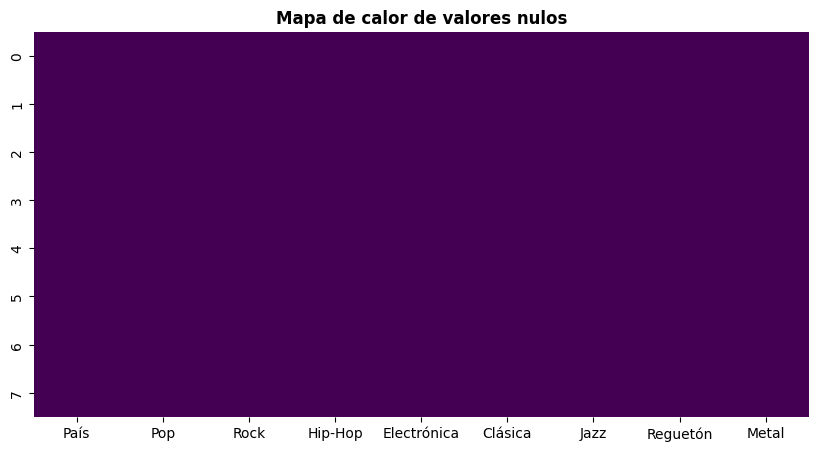

In [6]:
# Exploración inicial

tabla(df.head(5),title="Primeras 5 filas")

print(f"Información inicial del data set:")

df.columns= df.columns.str.replace(" ", "") # Cambio de nombres de columnas
tabla(df.info())

print("\n Dimensiones del DataFrame:", df.shape)

# Deteccion de duplicados
print(f'Número de duplicados: {df.duplicated().sum()}')

# Detección de valores nulos
tabla(df.isnull().sum(), title=" Valores nulos:")

tabla(df.describe(),title=" Estadísticas descriptivas:")

# Visualización nulos

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=True,
            color=sns.color_palette("viridis")[3])
plt.title("Mapa de calor de valores nulos", fontsize=12, fontweight="bold")
plt.show()

## 2. Diseño y entrenamiento del modelo (5 puntos)
- Diseña una **red neuronal** con:  
  - Capa de entrada con tantas neuronas como variables predictoras.  
  - **≥ 2 capas ocultas** con activaciones adecuadas.  
  - Capa de salida con **1 neurona** (predicción de tasa de natalidad).  
- Prueba distintas **funciones de activación** y evalúa su impacto.  
- Utiliza **optimizadores** adecuados y experimenta con diferentes *learning rates*.  
- Aplica **regularización** (*dropout* o L2) para evitar sobreajuste.  
- Entrena el modelo con una **función de pérdida** apropiada para regresión.


## 3. Evaluación y optimización del modelo (3 puntos)
- Evalúa el desempeño con el **conjunto de prueba**.  
- Ajusta **hiperparámetros** para mejorar el rendimiento.  
- Analiza el **impacto de cada variable** en la predicción.  
- Realiza **predicciones** y compáralas con datos reales.


## 4. Análisis de resultados y reflexión final (1 punto)
- Indica qué **variables** fueron más influyentes.  
- Relaciona resultados con **tendencias demográficas**.  
- Propón **mejoras** para futuras versiones del modelo.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el **dataset** proporcionado.  
- Incluye **código comentado** con tu implementación.  
- **Comprime** tu proyecto (`.zip`/`.rar`).  
- Adjunta un documento con **reflexiones analíticas**.  
- Sube tu entrega a la **plataforma**.
